
# **Cleaning, Evaluation, and Selection of Generated Molecules**

This notebook evaluates and post-processes molecules generated by the REINVENT model across multiple sampling outputs. Generated SMILES are validated, canonicalized, and deduplicated using RDKit, then assessed against the training and validation sets using metrics such as validity, uniqueness, novelty, scaffold recall, and similarity to validation molecules.

A policy-based selection strategy is used to identify the best sampling file by prioritizing high scaffold recall while maintaining strong novelty relative to the training set. The selected molecules are then cleaned again, filtered for novelty, and reduced to a final set of up to 1,000 unique molecules, which are saved in CSV and SMI formats. The notebook also visualizes a small random sample of the selected molecules for quick structural inspection.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 55.6 MB/s eta 0:00:00


In [ ]:
# ==== A) Setup ====
from pathlib import Path
import csv, re, statistics as stats
import pandas as pd
from IPython.display import SVG, display

# RDKit (installed in THIS notebook kernel)
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs




In [ ]:
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")


# **1) Environment Setup and Target Configuration**

In [ ]:

# ---- choose target here ----
targets = ["5-HT6", "ache", "bace1", "buche", "esr1", "3beta", "mao-b"]
target  = targets[6]

# Root for this target
TROOT    = Path(f"/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/{target}")
TRAIN_PATH = TROOT / "data" / "train.smi"
VAL_PATH   = TROOT / "data" / "val.smi"
SAMPLES    = TROOT / "samples"
REPORTS    = SAMPLES / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

print("Using:")
print("  train.smi:", TRAIN_PATH.exists(), TRAIN_PATH)
print("  val.smi  :", VAL_PATH.exists(), VAL_PATH)
print("  samples  :", SAMPLES.exists(), SAMPLES)


Using:
  train.smi: True /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/mao-b/data/train.smi
  val.smi  : True /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/mao-b/data/val.smi
  samples  : True /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/mao-b/samples


In [ ]:
assert TRAIN_PATH.exists(), f"Missing train.smi at {TRAIN_PATH}"
assert VAL_PATH.exists(),   f"Missing val.smi at {VAL_PATH}"
assert SAMPLES.exists(),    f"Missing samples dir at {SAMPLES}"

# **2) Helper Functions for Molecular Processing**

In [ ]:
# ==== B) Helpers ====

def canon(s: str):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m else None

def scaffold(smiles: str):
    m = Chem.MolFromSmiles(smiles)
    if not m: return None
    core = MurckoScaffold.GetScaffoldForMol(m)
    return Chem.MolToSmiles(core, canonical=True) if core else None

def ecfp4(smiles: str):
    m = Chem.MolFromSmiles(smiles)
    return AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048) if m else None

def read_smi(path: Path):
    return [l.strip() for l in path.read_text(encoding="utf-8").splitlines() if l.strip()]

def read_sampling_csv(path: Path):
    with open(path, newline="", encoding="utf-8") as f:
        rdr = csv.DictReader(f)
        cols = [c.strip() for c in (rdr.fieldnames or [])]
        smi_col = next((c for c in cols if "smile" in c.lower()), cols[0])
        return [(row.get(smi_col) or "").strip() for row in rdr]

def epoch_from_name(p: Path):
    """
    Extract epoch number from common patterns, else return 999 for 'final'.
    Handles:
      sampling_epoch_06.csv         -> 6
      TL_agent.model.6.chkpt        -> 6
      TL_agent_E06.model            -> 6
      sampling_final.csv            -> 999
    """
    name = p.name
    m = re.search(r"epoch[_\-]?(\d+)", name)               # sampling_epoch_06.csv
    if m: return int(m.group(1))
    m = re.search(r"\.model\.(\d+)\.chkpt$", name)         # TL_agent.model.6.chkpt
    if m: return int(m.group(1))
    m = re.search(r"[_\-]E(\d+)", name)                    # TL_agent_E06.model
    if m: return int(m.group(1))
    return 999


# **3) Load reference sets (train/val)**

In [ ]:
# ==== C) Load canonical train/val sets once ====
train_can = {c for s in read_smi(TRAIN_PATH) if (c := canon(s))}
val_can   = {c for s in read_smi(VAL_PATH)   if (c := canon(s))}
val_scaffs = {scaffold(s) for s in val_can if scaffold(s)}
val_fps = [fp for fp in (ecfp4(s) for s in val_can) if fp is not None]
print(f"Loaded train={len(train_can)}, val={len(val_can)} (canonical).")


Loaded train=2513, val=444 (canonical).


## **Post-generation filtering and final set construction**

After model selection, the winning sampling file was identified from best_epoch.txt, which records the name of the highest-ranked sampling*.csv according to the scaffold-first policy (maximize Bemis–Murcko scaffold recall subject to novelty vs. train ≥ 0.80).

The corresponding CSV was then processed with RDKit in four steps:

(i) validity check, where each string was parsed to a molecular graph (Chem.MolFromSmiles) and invalid entries were removed;

(ii) canonicalization, converting all valid SMILES to their canonical forms (Chem.MolToSmiles) to ensure consistent representation;

(iii) de-duplication, collapsing exact canonical duplicates to enforce molecular uniqueness; and
(iv) novelty enforcement relative to the training set, where any canonical SMILES present in train.smi were excluded.

When ≥1,000 novel molecules were available, the final deliverable was defined as the first 1,000 molecules from the cleaned, canonical, unique, and novel list; otherwise, the set was filled up to 1,000 using the remaining clean uniques (not present in the training set shortfall). The finalized collection was written in parallel as clean_smiles_1k.csv (tabular) and clean_smiles_1k.smi (line-delimited SMILES) under <target>/samples/. This procedure guarantees that the reported compounds are valid, unique, and (to the extent possible) novel with respect to the training data, and it is reproducible from the saved artifacts (train.smi, best_epoch.txt, and the winning sampling*.csv).

# **4) Evaluate Generated Molecules Across Sampling Epochs**

In [ ]:
# ==== D) Evaluate sampling files & save metrics ====
sampling_files = sorted(SAMPLES.glob("sampling*.csv"),
                        key=lambda p: (epoch_from_name(p), p.name))
if not sampling_files:
    raise FileNotFoundError(f"No sampling*.csv files found under {SAMPLES}")

rows = []
for sf in sampling_files:
    raw  = [s for s in read_sampling_csv(sf) if s]
    valid= [c for s in raw if (c := canon(s))]
    uniq = list(dict.fromkeys(valid))  # dedupe, preserve order

    validity    = len(valid)/max(1,len(raw))
    uniqueness  = len(uniq)/max(1,len(valid))
    novelty_tr  = len([s for s in uniq if s not in train_can]) / max(1,len(uniq))
    novelty_val = len([s for s in uniq if s not in val_can])   / max(1,len(uniq))

    samp_scaffs = {scaffold(s) for s in uniq if scaffold(s)}
    val_sc_recall = (len(val_scaffs & samp_scaffs) / max(1,len(val_scaffs))) if val_scaffs else 0.0

    samp_fps = [fp for fp in (ecfp4(s) for s in uniq) if fp is not None]
    nn_sims = [max(DataStructs.BulkTanimotoSimilarity(fp, val_fps)) for fp in samp_fps] if (val_fps and samp_fps) else []
    nn_p50 = round(stats.median(nn_sims), 3) if nn_sims else None
    nn_p90 = round(sorted(nn_sims)[int(0.9*len(nn_sims))], 3) if nn_sims else None

    # composite score (tweak weights if desired)
    nn_p50_safe = nn_p50 if nn_p50 is not None else 0.5
    score = (0.3*novelty_tr + 0.2*novelty_val + 0.3*val_sc_recall + 0.2*(1 - nn_p50_safe))

    rows.append({
        "target": target,
        "file": sf.name,
        "epoch": epoch_from_name(sf),
        "n_raw": len(raw),
        "n_valid": len(valid),
        "n_unique": len(uniq),
        "validity": round(validity,3),
        "uniqueness": round(uniqueness,3),
        "novelty_vs_train": round(novelty_tr,3),
        "novelty_vs_val": round(novelty_val,3),
        "val_scaffold_recall": round(val_sc_recall,3),
        "nn_sim_to_val_p50": nn_p50,
        "nn_sim_to_val_p90": nn_p90,
        "composite_score": round(score,3),
    })

metrics_df = pd.DataFrame(rows).sort_values(["epoch","file"]).reset_index(drop=True)
metrics_path = REPORTS / "metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Saved metrics →", metrics_path)
metrics_df.tail(len(rows))


Saved metrics → /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/mao-b/samples/reports/metrics.csv


,target,file,epoch,n_raw,n_valid,n_unique,validity,uniqueness,novelty_vs_train,novelty_vs_val,val_scaffold_recall,nn_sim_to_val_p50,nn_sim_to_val_p90,composite_score
0,mao-b,sampling_epoch_02.csv,2,1972,1972,1972,1.0,1.0,0.993,1.000,0.145,0.283,0.456,0.685
1,mao-b,sampling_epoch_04.csv,4,1957,1957,1957,1.0,1.0,0.979,0.996,0.249,0.304,0.556,0.707
2,mao-b,sampling_epoch_06.csv,6,1958,1958,1958,1.0,1.0,0.964,0.996,0.285,0.329,0.607,0.708
3,mao-b,sampling_epoch_08.csv,8,1957,1957,1957,1.0,1.0,0.953,0.997,0.281,0.344,0.625,0.701
4,mao-b,sampling_epoch_10.csv,10,1938,1938,1938,1.0,1.0,0.941,0.994,0.305,0.362,0.659,0.700
5,mao-b,sampling_epoch_12.csv,12,1940,1940,1940,1.0,1.0,0.917,0.992,0.317,0.375,0.681,0.694
6,mao-b,sampling_final.csv,999,1940,1940,1940,1.0,1.0,0.917,0.992,0.317,0.375,0.681,0.694


# **5) Policy-Based Selection of the Best Sampling Epoch**

In [ ]:
# ==== E) Policy-based selection: maximize scaffold recall, subject to novelty ≥ 0.80 ====

# 1) hard gates (you can add validity/uniqueness gates if you like)
NOVELTY_TRAIN_MIN = 0.80

candidates = metrics_df[
    (metrics_df["novelty_vs_train"] >= NOVELTY_TRAIN_MIN)
].copy()

if candidates.empty:
    print(f"[Warn] No epochs satisfy novelty_vs_train ≥ {NOVELTY_TRAIN_MIN:.2f}. "
          "Falling back to best novelty_vs_train, then scaffold recall.")
    # fallback: take top 3 by novelty_vs_train, then pick max scaffold recall among them
    top_by_novelty = metrics_df.sort_values("novelty_vs_train", ascending=False).head(3)
    candidates = top_by_novelty.copy()

# 2) rank: primary = scaffold recall (desc), tie1 = lower NN similarity to val (i.e., (1 - nn_p50) desc),
#    tie2 = novelty_vs_val (desc) to still encourage novelty vs holdout
def inv(x):  # helper for sorting when None can appear
    return x if x is not None else 1.0  # treat missing nn_p50 as low similarity (conservative)

candidates = candidates.sort_values(
    by=[
        "val_scaffold_recall",                # highest first
        # sort by (1 - nn_p50) -> implement as nn_p50 ascending (None treated as 0.5)
        "nn_sim_to_val_p50",
        "novelty_vs_val"
    ],
    ascending=[False, True, False],
    kind="mergesort",  # stable
)

best_row  = candidates.iloc[0]
best_file = best_row["file"]

# 3) persist choice
(REPORTS / "best_epoch.txt").write_text(best_file + "\n", encoding="utf-8")

print("Selection policy: maximize scaffold recall subject to novelty_vs_train ≥ 0.80")
print("Chosen file:", best_file)
display(best_row.to_frame().T)


Selection policy: maximize scaffold recall subject to novelty_vs_train ≥ 0.80
Chosen file: sampling_epoch_12.csv


,target,file,epoch,n_raw,n_valid,n_unique,validity,uniqueness,novelty_vs_train,novelty_vs_val,val_scaffold_recall,nn_sim_to_val_p50,nn_sim_to_val_p90,composite_score
5,mao-b,sampling_epoch_12.csv,12,1940,1940,1940,1.0,1.0,0.917,0.992,0.317,0.375,0.681,0.694


# **6) Final Cleaning and Extraction of 1,000 Molecules**

In [ ]:
# ==== Finalize & save the best clean SMILES set ====
# Uses the winner recorded in reports/best_epoch.txt
from pathlib import Path
import csv, pandas as pd
from rdkit import Chem

# Paths
best_csv_name = (REPORTS/"best_epoch.txt").read_text(encoding="utf-8").strip()
BEST_CSV      = SAMPLES / best_csv_name
OUT_CSV       = SAMPLES / "clean_smiles_1k.csv"
OUT_SMI       = SAMPLES / "clean_smiles_1k.smi"

# Load training (for optional re-check of novelty) and the winning samples
train_set = {c for s in (TRAIN_PATH.read_text(encoding="utf-8").splitlines())
             if (c := canon(s.strip()))}

with open(BEST_CSV, newline="", encoding="utf-8") as f:
    rdr = csv.DictReader(f)
    cols = [c.strip() for c in (rdr.fieldnames or [])]
    smi_col = next((c for c in cols if "smile" in c.lower()), cols[0])
    raw = [(row.get(smi_col) or "").strip() for row in rdr if (row.get(smi_col) or "").strip()]

# Validate + canonicalize + dedupe
seen, clean = set(), []
for s in raw:
    m = Chem.MolFromSmiles(s)
    if not m:
        continue
    can = Chem.MolToSmiles(m, canonical=True)
    if can in seen:
        continue
    seen.add(can); clean.append(can)

# (Optional, consistent with policy) enforce novelty vs TRAIN here too
novel_clean = [s for s in clean if s not in train_set]

# Cap to 1000 (change if you need a different size)
final_1k = novel_clean[:1000] if len(novel_clean) >= 1000 else clean[:1000]

if len(clean) == 0:
    raise ValueError("No valid molecules in the winning sample.")
if len(set(clean)) < min(1000, len(clean)):
    print("[Note] Deduping reduced the set; proceeding with unique canonical SMILES.")


# Save final deliverables (same molecules in both)
pd.DataFrame({"SMILES": final_1k}).to_csv(OUT_CSV, index=False)
OUT_SMI.write_text("\n".join(final_1k), encoding="utf-8")

print(f"[Final] Wrote {len(final_1k)} molecules from {BEST_CSV.name}")
print(" CSV →", OUT_CSV)
print(" SMI →", OUT_SMI)


[Final] Wrote 1000 molecules from sampling_epoch_12.csv
 CSV → /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/mao-b/samples/clean_smiles_1k.csv
 SMI → /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/GenAI/reinvent/mao-b/samples/clean_smiles_1k.smi


# **7) Visualization of Generated Molecules**

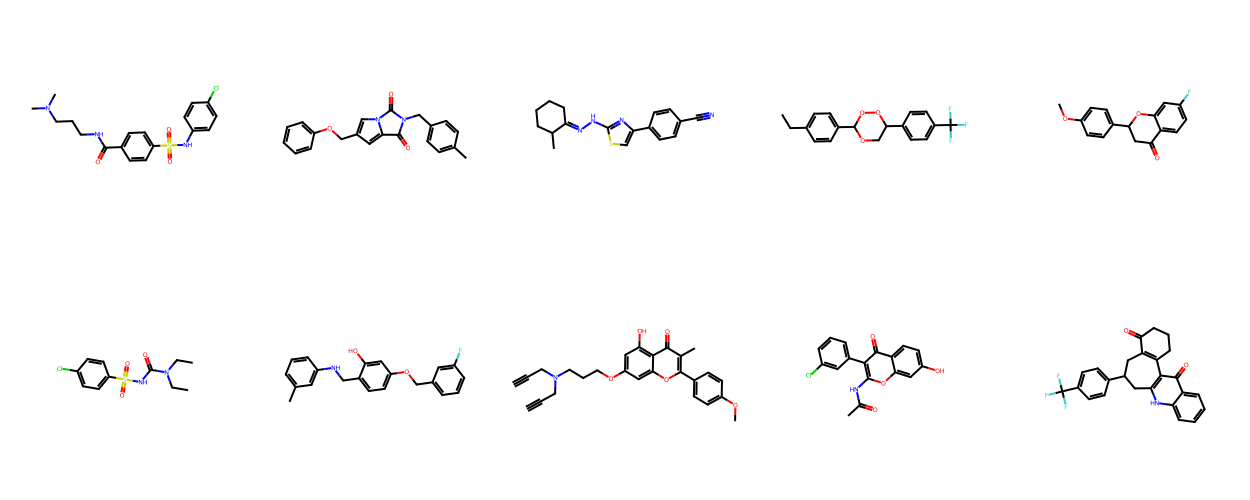

In [ ]:
# ==== F) Visualize 10 molecules from the winner ====
best_csv = SAMPLES / best_file

with open(best_csv, newline="", encoding="utf-8") as f:
    rdr = csv.DictReader(f)
    cols = [c.strip() for c in (rdr.fieldnames or [])]
    smi_col = next((c for c in cols if "smile" in c.lower()), cols[0])
    raw = [(row.get(smi_col) or "").strip() for row in rdr]

valid  = [c for s in raw if (c := canon(s))]
uniq   = list(dict.fromkeys(valid))

import random
k = min(10, len(uniq))
if k == 0:
    print("No molecules to draw.")
else:
    picks = random.sample(uniq, k)
    mols  = [Chem.MolFromSmiles(s) for s in picks if Chem.MolFromSmiles(s) is not None]
    svg   = Draw.MolsToGridImage(mols, molsPerRow=5, useSVG=True, subImgSize=(250,250))
    display(SVG(svg.data if hasattr(svg, "data") else str(svg)))
